# Optimisation Scans Testing

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
import numpy as np
import matplotlib.pyplot as plt

---
## MOT Optimisation

In [49]:
from scipy.optimize import curve_fit
from scipy.ndimage import center_of_mass, label

gamma = 1e3 / 194902.8581 # mm / px
MRb = 1.44316e-25  # kg
kB = 1.380649e-23  # J/K

def gaussian2D(x, y, A, x0, y0, sx, sy, theta, offset):
    x_rot = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    y_rot = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    return A * np.exp(-((x_rot**2 / (2 * sx**2)) + (y_rot**2 / (2 * sy**2)))) + offset

def fit_gaussian(img):
    x = np.arange(img.shape[1])
    y = np.arange(img.shape[0])
    x, y = np.meshgrid(x, y)
    com_y, com_x = center_of_mass(img)
    p0 = (img.max() - img.min(), com_x, com_y, 70, 70, 0, img.min())  # Initial guess for parameters
    popt, pcov = curve_fit(lambda xy, A, x0, y0, sx, sy, theta, offset: gaussian2D(xy[0], xy[1], A, x0, y0, sx, sy, theta, offset).ravel(), (x.ravel(), y.ravel()), img.ravel(), p0=p0)
    A_fit, x0_fit, y0_fit, sx_fit, sy_fit, theta_fit, offset_fit = popt
    sx_fit, sy_fit = sorted([abs(sx_fit), abs(sy_fit)], reverse=True)
    return {
        "A": A_fit, "x0": x0_fit, "y0": y0_fit, "sx": abs(sx_fit), "sy": abs(sy_fit), "theta": theta_fit, "offset": offset_fit
    }

# Write a function which takes an image, an x and y position, and a window, then sums the pixels in that window and returns the sum. The window should be a square of size window_size centered on (x, y).
def get_total_counts(img, x, y, window_size):
    half_window = window_size // 2
    x_min = max(x - half_window, 0)
    x_max = min(x + half_window + 1, img.shape[1])
    y_min = max(y - half_window, 0)
    y_max = min(y + half_window + 1, img.shape[0])
    return np.sum(img[y_min:y_max, x_min:x_max])

In [36]:
exp : MotMasterClient = MotMasterClient()

Rb MotMasterClient initialised.


In [6]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.


In [97]:
exp.close()
motcam.close()

MotMasterClient closed.
Thorlabs TLCamera - motcam - closed.


In [37]:
motcam.set_trigger_source("bulb")
motcam.set_roi(0, 4000, 0, 4000)

exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

{'ok': True,
 'command': 'call_interface',
 'method': 'set_motmaster_experiment',
 'state': 'accepted'}

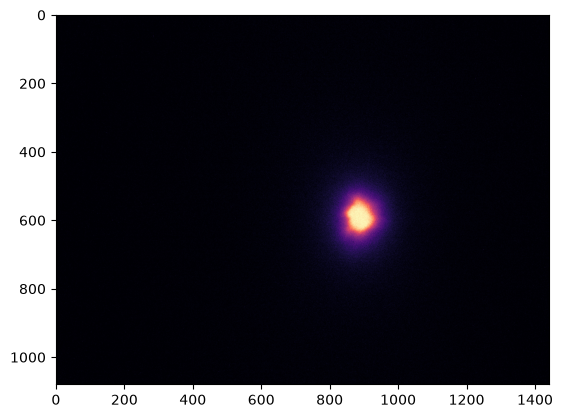

In [170]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

### Find MOT Centre

MOT detected at (x, y): (936, 555)


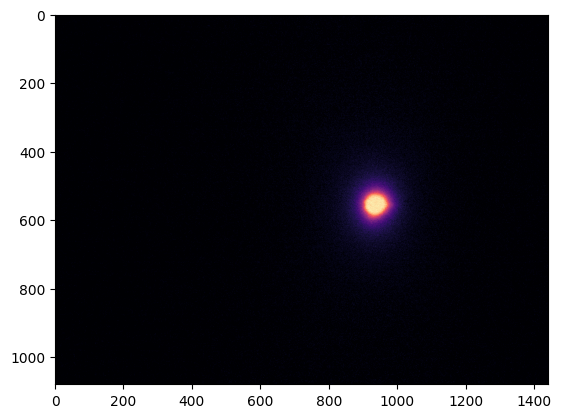

In [62]:
# Get centre of MOT
img_it = 10
bg_it = 2
exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVCO1": 4.5, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVCO1": 4.5, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
plt.imshow(img_mean, cmap='magma', vmin=0)
try:
    gaussian_params = fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

### Find Resonances

Cooling VCO resonance: 4.7368421052631575


Text(0, 0.5, 'Total Counts (a.u.)')

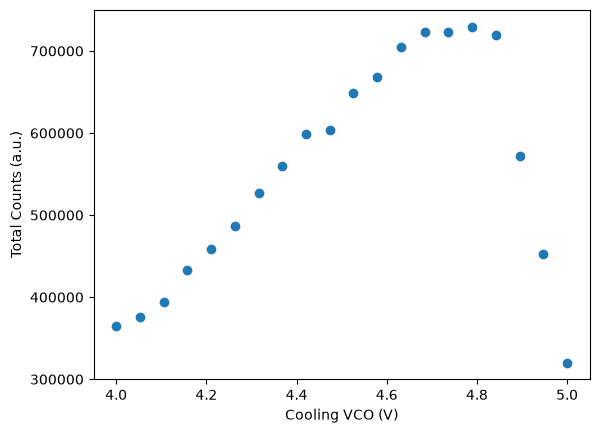

In [104]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(4.0, 5.0, 20)
counts = []

print(f"Scanning imaging repump VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgCoolVCO1": vco, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tcMOTccValue": 0.0})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgCoolVCO1": vco, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVCO1": 4.0, "tImgRepVVA1": 4.0})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)

counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
cool_vco_resonance = VCOList[max_index]
print(f"Cooling VCO resonance: {cool_vco_resonance}")

plt.scatter(VCOList, counts)
plt.xlabel("Cooling VCO (V)")
plt.ylabel("Total Counts (a.u.)")

Repump VCO resonance: 5.0


Text(0, 0.5, 'Total Counts (a.u.)')

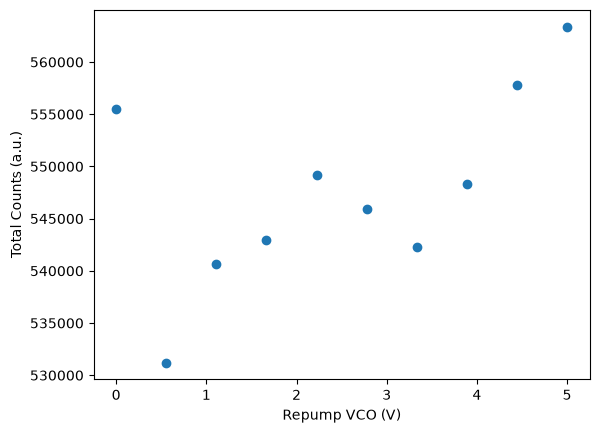

In [112]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(0.0, 5.0, 10)
counts = []

print(f"Scanning imaging repump VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgRepVCO1": vco, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tcMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tImgRepVCO1": vco, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    
counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
rep_vco_resonance = VCOList[max_index]
print(f"Repump VCO resonance: {rep_vco_resonance}")
plt.scatter(VCOList, counts, label='Raw Counts')
plt.xlabel("Repump VCO (V)")
plt.ylabel("Total Counts (a.u.)")

### MOT Number

Cooling VCO MOT resonance: 4.2631578947368425


Text(0, 0.5, 'Total Counts (a.u.)')

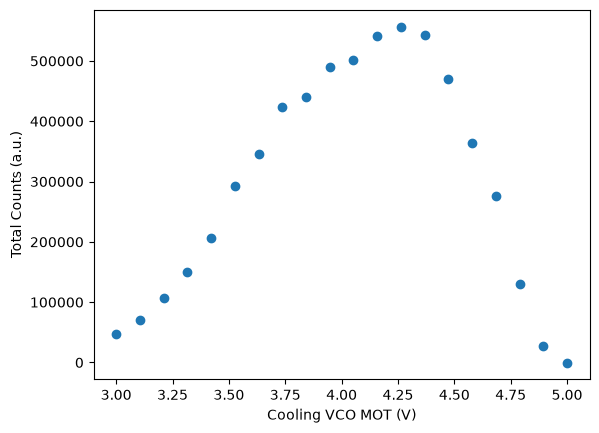

In [113]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(3.0, 5.0, 20)
counts = []

print(f"Scanning MOT cooling VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": vco, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tcMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": vco,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)

counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
cool_vco_mot = VCOList[max_index]
print(f"Cooling VCO MOT resonance: {cool_vco_mot}")
plt.scatter(VCOList, counts, label='Raw Counts')
plt.xlabel("Cooling VCO MOT (V)")
plt.ylabel("Total Counts (a.u.)")

Repump VCO MOT resonance: 1.5789473684210527


Text(0, 0.5, 'Total Counts (a.u.)')

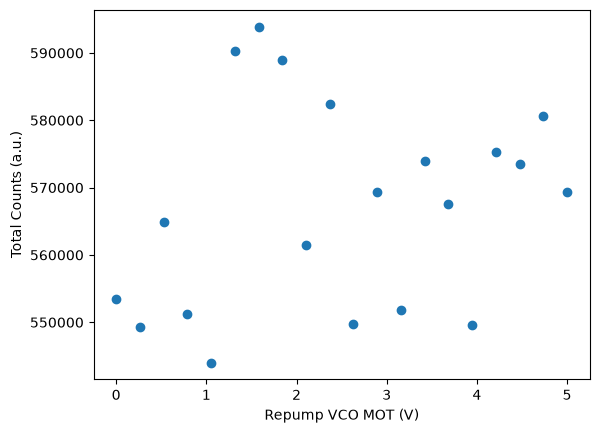

In [115]:
from scipy.signal import savgol_filter

img_it = 10
bg_it = 2

VCOList = np.linspace(0.0, 5.0, 20)
counts = []

print(f"Scanning MOT repump VCO...")
for vco in VCOList:
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": vco, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": vco, "tMOTLoadCoolVCO": cool_vco_mot,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 30000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)

counts_smooth = savgol_filter(counts, 3, 1)  # window size 11, polynomial order 3
max_index = np.argmax(counts_smooth)
rep_vco_mot = VCOList[max_index]
print(f"Repump VCO MOT resonance: {rep_vco_mot}")
plt.scatter(VCOList, counts, label='Raw Counts')
plt.xlabel("Repump VCO MOT (V)")
plt.ylabel("Total Counts (a.u.)")

### MOT/Molasses Temp

In [186]:
n_it = 20
img_it = 5
bg_it = 2

tau_list = np.arange(1, 1000, 1000/n_it)
images = []

print(f"Running TOF temperature measurement...")
for it, tau in enumerate(tau_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    images.append(img_mean)
    print(f"Iteration {str(it+1).zfill(2)}/{n_it}  |  TOF: {tau/100:.2f} ms")

Running TOF temperature measurement...
Iteration 1/20  |  TOF: 0.01 ms
Iteration 2/20  |  TOF: 0.51 ms
Iteration 3/20  |  TOF: 1.01 ms
Iteration 4/20  |  TOF: 1.51 ms
Iteration 5/20  |  TOF: 2.01 ms
Iteration 6/20  |  TOF: 2.51 ms
Iteration 7/20  |  TOF: 3.01 ms
Iteration 8/20  |  TOF: 3.51 ms
Iteration 9/20  |  TOF: 4.01 ms
Iteration 10/20  |  TOF: 4.51 ms
Iteration 11/20  |  TOF: 5.01 ms
Iteration 12/20  |  TOF: 5.51 ms
Iteration 13/20  |  TOF: 6.01 ms
Iteration 14/20  |  TOF: 6.51 ms
Iteration 15/20  |  TOF: 7.01 ms
Iteration 16/20  |  TOF: 7.51 ms
Iteration 17/20  |  TOF: 8.01 ms
Iteration 18/20  |  TOF: 8.51 ms
Iteration 19/20  |  TOF: 9.01 ms
Iteration 20/20  |  TOF: 9.51 ms


Extracting Gaussian fit parameters...
Iteration 01/20  |  TOF: 0.01 ms  |  Amplitude: 1049.43  |  Centre: (888, 586)  |  Widths: (sx: 53.116, sy: 42.584)
Iteration 02/20  |  TOF: 0.51 ms  |  Amplitude: 1042.34  |  Centre: (890, 589)  |  Widths: (sx: 53.2458, sy: 44.5004)
Iteration 03/20  |  TOF: 1.01 ms  |  Amplitude: 1036.33  |  Centre: (891, 590)  |  Widths: (sx: 54.1554, sy: 44.4593)
Iteration 04/20  |  TOF: 1.51 ms  |  Amplitude: 990.476  |  Centre: (891, 590)  |  Widths: (sx: 56.6108, sy: 47.13)
Iteration 05/20  |  TOF: 2.01 ms  |  Amplitude: 970.427  |  Centre: (893, 588)  |  Widths: (sx: 56.7016, sy: 48.5769)
Iteration 06/20  |  TOF: 2.51 ms  |  Amplitude: 890.738  |  Centre: (894, 593)  |  Widths: (sx: 61.0525, sy: 51.2515)
Iteration 07/20  |  TOF: 3.01 ms  |  Amplitude: 812.669  |  Centre: (893, 590)  |  Widths: (sx: 63.7604, sy: 54.2284)
Iteration 08/20  |  TOF: 3.51 ms  |  Amplitude: 708.292  |  Centre: (900, 592)  |  Widths: (sx: 68.1997, sy: 58.7133)
Iteration 09/20  |  TO

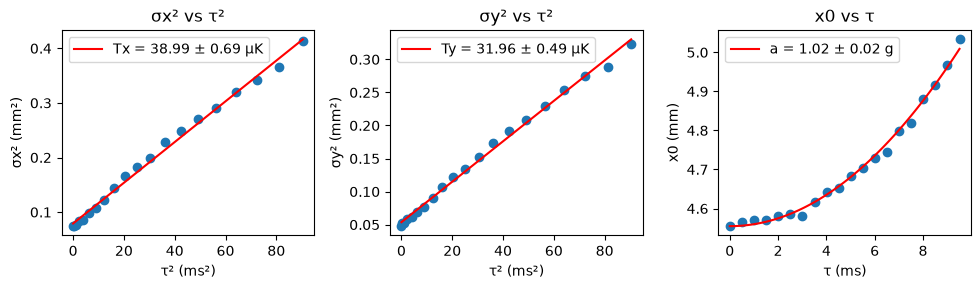

In [ ]:
print(f"Extracting Gaussian fit parameters...")

def extract_cloud_temperature(images, tau_list, show_plots=True):
    x0_list, y0_list, sx_list, sy_list = [], [], [], []
    for it, img in enumerate(images):
        gaussian_params = fit_gaussian(img)
        amp, centre_x, centre_y, sx, sy = gaussian_params["A"], int(gaussian_params["x0"]), int(gaussian_params["y0"]), gaussian_params["sx"], gaussian_params["sy"]
        print(f"Iteration {str(it+1).zfill(2)}/{n_it}  |  TOF: {tau_list[it]/100:.6g} ms  |  Amplitude: {amp:.6g}  |  Centre: ({centre_x}, {centre_y})  |  Widths: (sx: {sx:.6g}, sy: {sy:.6g})")
        x0_list.append(centre_x)
        y0_list.append(centre_y)
        sx_list.append(sx)
        sy_list.append(sy)

    tau_list_ms = tau_list * 1 / 100
    sx_array = np.array(sx_list) * gamma
    sy_array = np.array(sy_list) * gamma
    x0_array = np.array(x0_list) * gamma
    y0_array = np.array(y0_list) * gamma

    lin_fit = lambda x, m, c: m * x + c
    px, pcovx = curve_fit(lin_fit, tau_list_ms**2, sx_array**2)
    py, pcovy = curve_fit(lin_fit, tau_list_ms**2, sy_array**2)
    t2_fit = np.linspace(0, tau_list_ms[-1]**2, 100)
    sx2_fit = lin_fit(t2_fit, *px)
    sy2_fit = lin_fit(t2_fit, *py)
    mx = px[0]  # slope for sx^2 vs tau^2
    my = py[0]  # slope for sy^2 vs tau^2
    Tx = mx * MRb / kB * 1e6
    Ty = my * MRb / kB * 1e6
    mx_err = np.sqrt(np.diag(pcovx))[0]
    my_err = np.sqrt(np.diag(pcovy))[0]
    Tx_err = mx_err * MRb / kB * 1e6
    Ty_err = my_err * MRb / kB * 1e6

    free_fall = lambda t, a, x0: 1/2 * a * t**2 + x0
    param1, pcov1 = curve_fit(free_fall, tau_list_ms, x0_array)
    t_fit = np.linspace(0, tau_list_ms[-1], 100)
    x0_fit = free_fall(t_fit, *param1)
    a = param1[0] # acceleration in pixels/ms²
    a_err = np.sqrt(np.diag(pcov1))[0]

    if show_plots:
        # Plot sx_array, sy_array, x0_array all three side by side with respect to tau_list_ms
        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1)
        plt.scatter(tau_list_ms**2, sx_array**2)
        plt.plot(t2_fit, sx2_fit, color='red', label=f"Tx = {Tx:.2f} ± {Tx_err:.2f} μK")
        plt.legend()
        plt.xlabel('τ² (ms²)')
        plt.ylabel('σx² (mm²)')
        plt.title('σx² vs τ²')

        plt.subplot(1, 3, 2)
        plt.scatter(tau_list_ms**2, sy_array**2)
        plt.plot(t2_fit, sy2_fit, color='red', label=f"Ty = {Ty:.2f} ± {Ty_err:.2f} μK")
        plt.legend()
        plt.xlabel('τ² (ms²)')
        plt.ylabel('σy² (mm²)')
        plt.title('σy² vs τ²')

        plt.subplot(1, 3, 3)
        plt.scatter(tau_list_ms, x0_array)
        plt.plot(t_fit, x0_fit, color='red', label=f"a = {a/(9.81/1000):.2f} ± {a_err/(9.81/1000):.2f} g")
        plt.legend()
        plt.xlabel('τ (ms)')
        plt.ylabel('x0 (mm)')
        plt.title('x0 vs τ')

        plt.tight_layout()
        plt.show()

    return {
        "Tx": Tx, "Tx_err": Tx_err, "Ty": Ty, "Ty_err": Ty_err, "a": a, "a_err": a_err
    }

In [188]:
n_it = 3
img_it = 10
bg_it = 2

tau_list = np.arange(200, 1000, 1000/n_it)
images = []

print(f"Running TOF temperature measurement...")
for it, tau in enumerate(tau_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot, "tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": rep_vco_mot, "tMOTLoadCoolVCO": cool_vco_mot,"tImgRepVCO1": rep_vco_resonance, "tImgCoolVCO1": cool_vco_resonance, "tDelay1": int(tau), "tMolassesDuration": 1000, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000 + int(tau)})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    images.append(img_mean)
    print(f"Iteration {it+1}/{n_it}  |  TOF: {tau/100:.2f} ms")

Running TOF temperature measurement...
Iteration 01/3  |  TOF: 2.00 ms
Iteration 02/3  |  TOF: 5.33 ms
Iteration 03/3  |  TOF: 8.67 ms


Extracting Gaussian fit parameters...
Iteration 01/3  |  TOF: 2 ms  |  Amplitude: 969.489  |  Centre: (891, 587)  |  Widths: (sx: 58.683, sy: 48.6707)
Iteration 02/3  |  TOF: 5.33333 ms  |  Amplitude: 515.168  |  Centre: (916, 590)  |  Widths: (sx: 84.3072, sy: 72.8524)
Iteration 03/3  |  TOF: 8.66667 ms  |  Amplitude: 282.881  |  Centre: (961, 595)  |  Widths: (sx: 115.781, sy: 103.203)


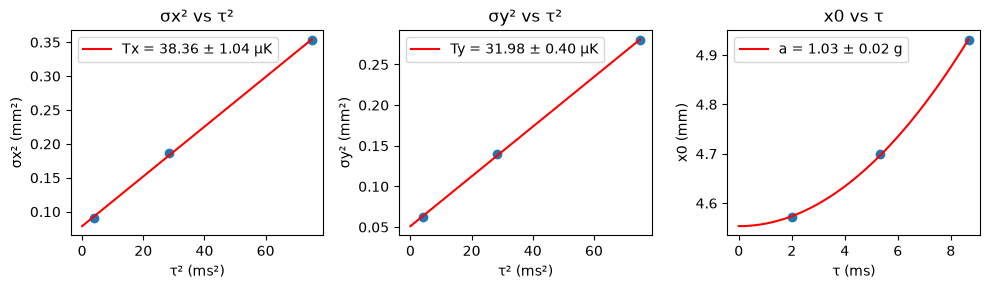

In [189]:
print(f"Extracting Gaussian fit parameters...")
x0_list, y0_list, sx_list, sy_list = [], [], [], []
for it, img in enumerate(images):
    gaussian_params = fit_gaussian(img)
    amp, centre_x, centre_y, sx, sy = gaussian_params["A"], int(gaussian_params["x0"]), int(gaussian_params["y0"]), gaussian_params["sx"], gaussian_params["sy"]
    print(f"Iteration {it+12}/{n_it}  |  TOF: {tau_list[it]/100:.6g} ms  |  Amplitude: {amp:.6g}  |  Centre: ({centre_x}, {centre_y})  |  Widths: (sx: {sx:.6g}, sy: {sy:.6g})")
    x0_list.append(centre_x)
    y0_list.append(centre_y)
    sx_list.append(sx)
    sy_list.append(sy)

tau_list_ms = tau_list * 1 / 100
tau_list_s = tau_list_ms * 1 / 1000
sx_array = np.array(sx_list) * gamma
sy_array = np.array(sy_list) * gamma
x0_array = np.array(x0_list) * gamma
y0_array = np.array(y0_list) * gamma

lin_fit = lambda x, m, c: m * x + c
px, pcovx = curve_fit(lin_fit, tau_list_ms**2, sx_array**2)
py, pcovy = curve_fit(lin_fit, tau_list_ms**2, sy_array**2)
t2_fit = np.linspace(0, tau_list_ms[-1]**2, 100)
sx2_fit = lin_fit(t2_fit, *px)
sy2_fit = lin_fit(t2_fit, *py)
mx = px[0]  # slope for sx^2 vs tau^2
my = py[0]  # slope for sy^2 vs tau^2
Tx = mx * MRb / kB * 1e6
Ty = my * MRb / kB * 1e6
mx_err = np.sqrt(np.diag(pcovx))[0]
my_err = np.sqrt(np.diag(pcovy))[0]
Tx_err = mx_err * MRb / kB * 1e6
Ty_err = my_err * MRb / kB * 1e6

free_fall = lambda t, a, x0: 1/2 * a * t**2 + x0
param1, pcov1 = curve_fit(free_fall, tau_list_ms, x0_array)
t_fit = np.linspace(0, tau_list_ms[-1], 100)
x0_fit = free_fall(t_fit, *param1)
a = param1[0] # acceleration in pixels/ms²
a_err = np.sqrt(np.diag(pcov1))[0]

# Plot sx_array, sy_array, x0_array all three side by side with respect to tau_list_ms
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.scatter(tau_list_ms**2, sx_array**2)
plt.plot(t2_fit, sx2_fit, color='red', label=f"Tx = {Tx:.2f} ± {Tx_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σx² (mm²)')
plt.title('σx² vs τ²')

plt.subplot(1, 3, 2)
plt.scatter(tau_list_ms**2, sy_array**2)
plt.plot(t2_fit, sy2_fit, color='red', label=f"Ty = {Ty:.2f} ± {Ty_err:.2f} μK")
plt.legend()
plt.xlabel('τ² (ms²)')
plt.ylabel('σy² (mm²)')
plt.title('σy² vs τ²')

plt.subplot(1, 3, 3)
plt.scatter(tau_list_ms, x0_array)
plt.plot(t_fit, x0_fit, color='red', label=f"a = {a/(9.81/1000):.2f} ± {a_err/(9.81/1000):.2f} g")
plt.legend()
plt.xlabel('τ (ms)')
plt.ylabel('x0 (mm)')
plt.title('x0 vs τ')

plt.tight_layout()
plt.show()

In [ ]:
from pytweezer.experiment.experiment_parameter_manager import DefaultExperimentalParameters

ExpParams = DefaultExperimentalParameters()

## Tweezer Optimisation

In [2]:
from pytweezer.drivers.slm import SLM
slm : SLM = SLM()

SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.169 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"


In [3]:
import pytweezer.phasemask as pm

dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.33e-06 | Uniformity: 43.26% | Min/Max ratio: 0.043
Iteration 010 | Mean-Squared Error: 2.73e-08 | Uniformity: 75.33% | Min/Max ratio: 0.343
Iteration 020 | Mean-Squared Error: 5.88e-09 | Uniformity: 75.99% | Min/Max ratio: 0.381
Iteration 030 | Mean-Squared Error: 1.27e-09 | Uniformity: 75.82% | Min/Max ratio: 0.378
Iteration 040 | Mean-Squared Error: 2.40e-09 | Uniformity: 75.99% | Min/Max ratio: 0.377
Iteration 050 | Mean-Squared Error: 1.61e-09 | Uniformity: 76.01% | Min/Max ratio: 0.387
Iteration 060 | Mean-Squared Er

In [8]:
from pytweezer.drivers.imagemX2 import ImagEMX2Camera

hamcam : ImagEMX2Camera = ImagEMX2Camera()

ImagEM X2 camera initialised.


In [9]:
from pytweezer import analysis as pyt

texp = pyt.TweezerExperimentAnalysis(day='26',month='05May', year='2026')

---- 26/05May/202026 Tweezer Experiment Analysis Initialised ----


In [10]:
hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

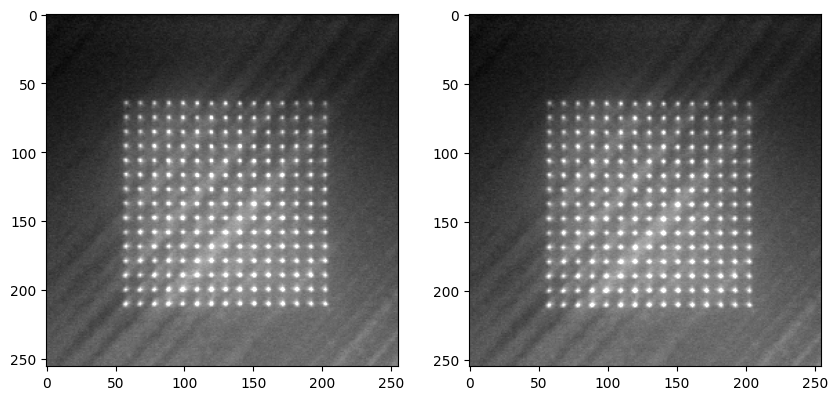

In [13]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("cool_vco_mot"), "tMOTLoadRepVCO": ExpParams.get_parameter("rep_vco_mot")})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
15x15 array detected.


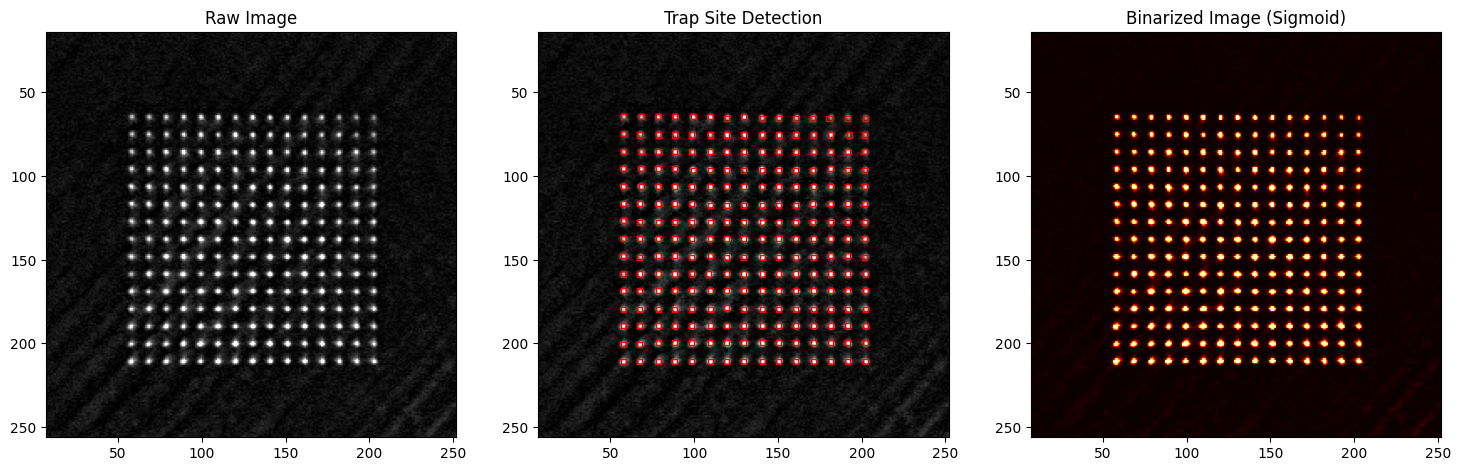

Trap (0, 0) Loading Probability : 10.00 %
Trap (0, 1) Loading Probability : 21.00 %
Trap (0, 2) Loading Probability : 31.00 %
Trap (0, 3) Loading Probability : 28.00 %
Trap (0, 4) Loading Probability : 44.00 %
Trap (0, 5) Loading Probability : 45.00 %
Trap (0, 6) Loading Probability : 42.00 %
Trap (0, 7) Loading Probability : 42.00 %
Trap (0, 8) Loading Probability : 48.00 %
Trap (0, 9) Loading Probability : 49.00 %
Trap (0, 10) Loading Probability : 35.00 %
Trap (0, 11) Loading Probability : 35.00 %
Trap (0, 12) Loading Probability : 2.00 %
Trap (0, 13) Loading Probability : 13.00 %
Trap (0, 14) Loading Probability : 4.00 %
Trap (1, 0) Loading Probability : 10.00 %
Trap (1, 1) Loading Probability : 37.00 %
Trap (1, 2) Loading Probability : 44.00 %
Trap (1, 3) Loading Probability : 43.00 %
Trap (1, 4) Loading Probability : 53.00 %
Trap (1, 5) Loading Probability : 37.00 %
Trap (1, 6) Loading Probability : 60.00 %
Trap (1, 7) Loading Probability : 44.00 %
Trap (1, 8) Loading Probability

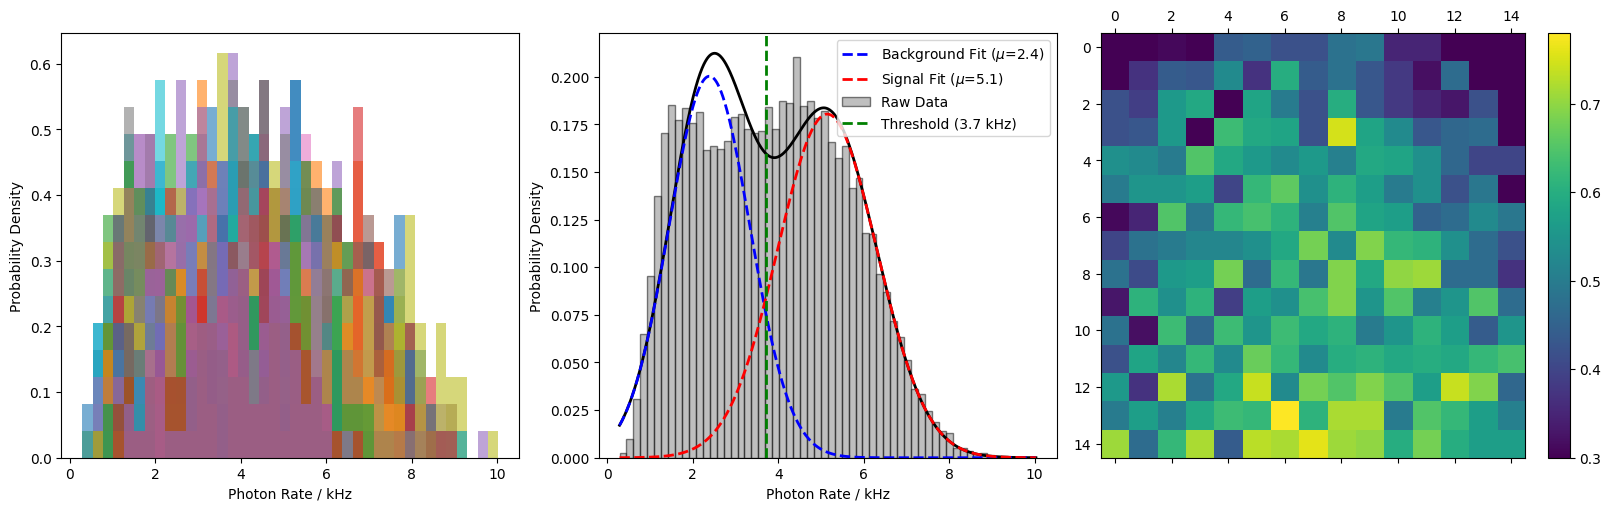

In [14]:
array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = pyt.detect_trap_sites(filtered_img_average, array_shape, detection_step=100)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

---

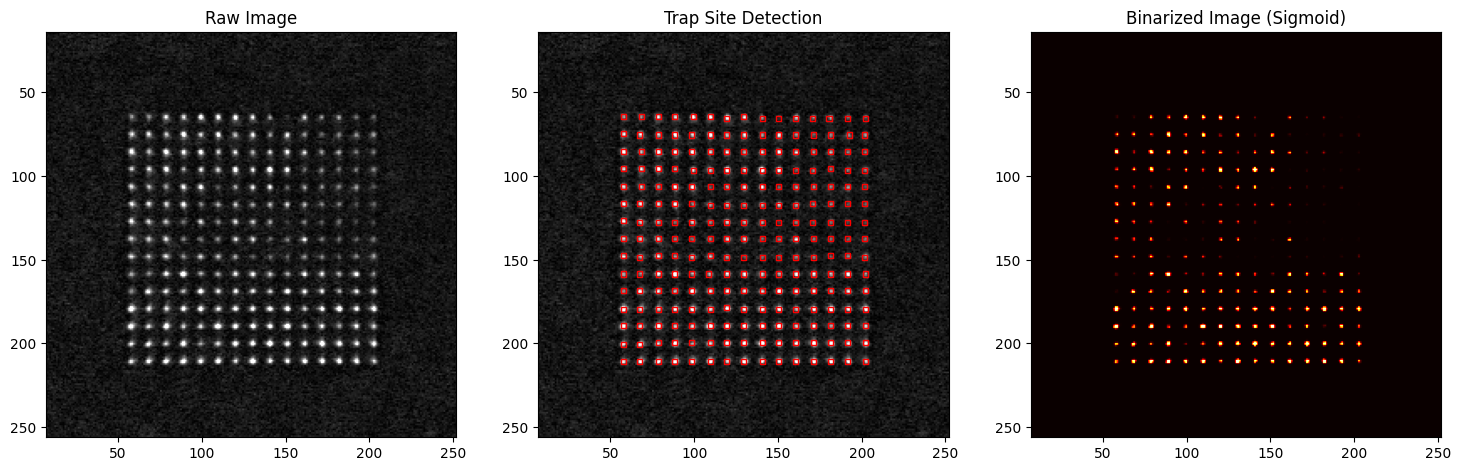

Trap (0, 0) Loading Probability : 22.00 %
Trap (0, 1) Loading Probability : 19.00 %
Trap (0, 2) Loading Probability : 33.00 %
Trap (0, 3) Loading Probability : 29.00 %
Trap (0, 4) Loading Probability : 38.00 %
Trap (0, 5) Loading Probability : 33.00 %
Trap (0, 6) Loading Probability : 37.00 %
Trap (0, 7) Loading Probability : 26.00 %
Trap (0, 8) Loading Probability : 19.00 %
Trap (0, 9) Loading Probability : 4.00 %
Trap (0, 10) Loading Probability : 26.00 %
Trap (0, 11) Loading Probability : 18.00 %
Trap (0, 12) Loading Probability : 23.00 %
Trap (0, 13) Loading Probability : 20.00 %
Trap (0, 14) Loading Probability : 16.00 %
Trap (1, 0) Loading Probability : 37.00 %
Trap (1, 1) Loading Probability : 33.00 %
Trap (1, 2) Loading Probability : 25.00 %
Trap (1, 3) Loading Probability : 39.00 %
Trap (1, 4) Loading Probability : 23.00 %
Trap (1, 5) Loading Probability : 36.00 %
Trap (1, 6) Loading Probability : 20.00 %
Trap (1, 7) Loading Probability : 28.00 %
Trap (1, 8) Loading Probabilit

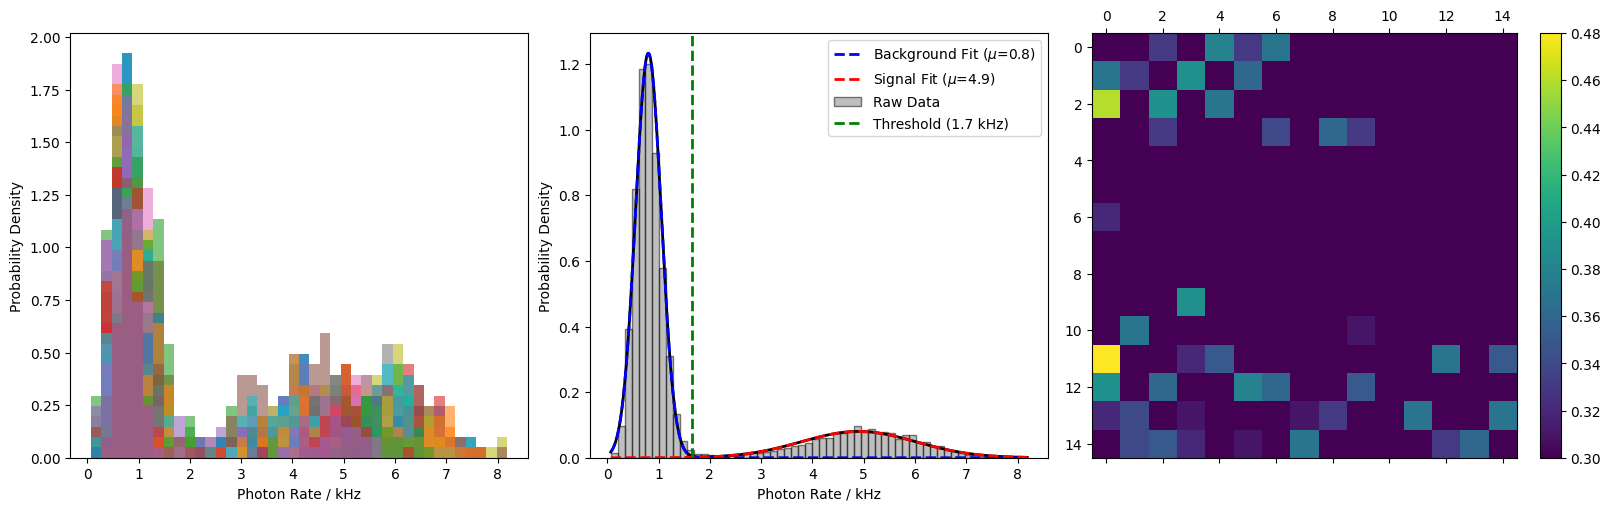

In [15]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("cool_vco_mot"), "tMOTLoadRepVCO": ExpParams.get_parameter("rep_vco_mot")})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=False, vmaxfactor=0.6, show_grid=True)

array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

### Bayesian Optimisation of MOT Shim Coil Values

In [38]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer
from skopt.plots import plot_convergence

In [57]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='ShimX', low=-2.0, high=2.0),
    Real(name='ShimY', low=-3.0, high=1.0),             
    Real(name='ShimZ', low=-0.8, high=-0.2)
]

# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(ShimX, ShimY, ShimZ):

    hamcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"),
                                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
                                    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
                                    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                                    "tMOTShimXccValue": ShimX, "tMOTShimYccValue": ShimY, "tMOTShimZccValue": ShimZ})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=False, threshold=2.0, window_size=window, binning=60, verbose=False, show_histogram=False)
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1 - mean_loading_probability

    print(f"\nExp Params: ShimX = {ShimX:.2f} V, ShimY = {ShimY:.3f} V, ShimZ = {ShimZ:.2f} V  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [58]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 40
n_initial_points = 5
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss)*100:.4f} %")
    print(f"  Best score: {(1-result.fun)*100:.4f} %")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Highest score achieved: {high_score:.4f}")
print("Best parameters:")
print(f"  - ShimX:   {best_params[0]:.4f}")
print(f"  - ShimY:   {best_params[1]:.4f}")
print(f"  - ShimZ:   {best_params[2]:.4f}")

Starting Bayesian Optimization with dynamic exploration...

Exp Params: ShimX = -1.48 V, ShimY = -2.702 V, ShimZ = -0.43 V  |  Mean Loading Probability = 0.4213
Iteration 1/40 (xi = 0.1000)
  Current score: 42.1333 %
  Best score: 42.1333 %

Exp Params: ShimX = -1.91 V, ShimY = -2.391 V, ShimZ = -0.23 V  |  Mean Loading Probability = 0.5636
Iteration 2/40 (xi = 0.0975)
  Current score: 56.3556 %
  Best score: 56.3556 %

Exp Params: ShimX = 1.22 V, ShimY = -2.023 V, ShimZ = -0.60 V  |  Mean Loading Probability = 0.2964
Iteration 3/40 (xi = 0.0949)
  Current score: 29.6444 %
  Best score: 56.3556 %

Exp Params: ShimX = -0.24 V, ShimY = -2.461 V, ShimZ = -0.44 V  |  Mean Loading Probability = 0.4191
Iteration 4/40 (xi = 0.0924)
  Current score: 41.9111 %
  Best score: 56.3556 %

Exp Params: ShimX = 1.91 V, ShimY = -2.646 V, ShimZ = -0.62 V  |  Mean Loading Probability = 0.2173
Iteration 5/40 (xi = 0.0898)
  Current score: 21.7333 %
  Best score: 56.3556 %

Exp Params: ShimX = -1.84 V, Shi

c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:846: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:848: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 


Exp Params: ShimX = -2.00 V, ShimY = 1.000 V, ShimZ = -0.36 V  |  Mean Loading Probability = 0.0000
Iteration 19/40 (xi = 0.0543)
  Current score: 0.0000 %
  Best score: 56.3556 %


c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:846: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:848: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 


Exp Params: ShimX = -1.99 V, ShimY = 0.696 V, ShimZ = -0.56 V  |  Mean Loading Probability = 0.0000
Iteration 20/40 (xi = 0.0518)
  Current score: 0.0000 %
  Best score: 56.3556 %


...

c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:846: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:848: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 


Exp Params: ShimX = -0.79 V, ShimY = 0.111 V, ShimZ = -0.20 V  |  Mean Loading Probability = 0.0000
Iteration 38/40 (xi = 0.0061)
  Current score: 0.0000 %
  Best score: 56.3556 %


c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:846: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:848: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 


Exp Params: ShimX = -1.30 V, ShimY = 0.986 V, ShimZ = -0.52 V  |  Mean Loading Probability = 0.0000
Iteration 39/40 (xi = 0.0035)
  Current score: 0.0000 %
  Best score: 56.3556 %

Exp Params: ShimX = -1.75 V, ShimY = 0.824 V, ShimZ = -0.23 V  |  Mean Loading Probability = 0.0000
Iteration 40/40 (xi = 0.0010)
  Current score: 0.0000 %
  Best score: 56.3556 %

Optimization Complete!
Highest score achieved: 0.5636
Best parameters:
  - ShimX:   -1.9143
  - ShimY:   -2.3912
  - ShimZ:   -0.2272


c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:846: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:848: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

In [59]:
ExpParams.add_parameter("tMOTShimXccValue", best_params[0])
ExpParams.add_parameter("tMOTShimYccValue", best_params[1])
ExpParams.add_parameter("tMOTShimZccValue", best_params[2])

### Bayesian Optimisation of Molasses Parameters

In [27]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='MolCoolVCO1', low=0.0, high=3.0),
    Real(name='MolRepVCO1', low=0.0, high=5.0),             
    Real(name='MolCoolVVA1', low=0.4, high=1.0),
    Real(name='MolRepVVA1', low=0.4, high=1.0),
    Real(name='MolCoolVCO2', low=0.0, high=3.0),
    Real(name='MolRepVCO2', low=0.0, high=5.0),             
    Real(name='MolCoolVVA2', low=0.4, high=1.0),
    Real(name='MolRepVVA2', low=0.4, high=1.0),
]

# Experiment and camera setup
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(MolCoolVCO1, MolRepVCO1, MolCoolVVA1, MolRepVVA1, MolCoolVCO2, MolRepVCO2, MolCoolVVA2, MolRepVVA2):

    hamcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("cool_vco_mot"), "tMOTLoadRepVCO": ExpParams.get_parameter("rep_vco_mot"),
                                     "tMolCoolVCO1": MolCoolVCO1, "tMolRepVCO1": MolRepVCO1, "tMolCoolVVA1": MolCoolVVA1, "tMolRepVVA1": MolRepVVA1,
                                     "tMolCoolVCO2": MolCoolVCO2, "tMolRepVCO2": MolRepVCO2, "tMolCoolVVA2": MolCoolVVA2, "tMolRepVVA2": MolRepVVA2})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=False, threshold=2.0, window_size=window, binning=60, verbose=False, show_histogram=False)
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1 - mean_loading_probability

    print(f"\nExp Params: MolCoolVCO1 = {MolCoolVCO1:.2f} V, MolRepVCO1 = {MolRepVCO1:.3f} V, MolCoolVVA1 = {MolCoolVVA1:.2f} V, MolRepVVA1 = {MolRepVVA1:.3f} V\n            MolCoolVCO2 = {MolCoolVCO2:.2f} V, MolRepVCO2 = {MolRepVCO2:.3f} V, MolCoolVVA2 = {MolCoolVVA2:.2f} V, MolRepVVA2 = {MolRepVVA2:.3f} V\nMean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [28]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 20
n_initial_points = 5
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss)*100:.4f} %")
    print(f"  Best score: {(1-result.fun)*100:.4f} %")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Highest score achieved: {high_score:.4f}")
print("Best parameters:")
print(f"  - MolCoolVCO1:   {best_params[0]:.4f}")
print(f"  - MolRepVCO1:    {best_params[1]:.4f}")
print(f"  - MolCoolVVA1:   {best_params[2]:.4f}")
print(f"  - MolRepVVA1:    {best_params[3]:.4f}")
print(f"  - MolCoolVCO2:   {best_params[4]:.4f}")
print(f"  - MolRepVCO2:    {best_params[5]:.4f}")
print(f"  - MolCoolVVA2:   {best_params[6]:.4f}")
print(f"  - MolRepVVA2:    {best_params[7]:.4f}")

Starting Bayesian Optimization with dynamic exploration...

Exp Params: MolCoolVCO1 = 0.39 V, MolRepVCO1 = 0.372 V, MolCoolVVA1 = 0.77 V, MolRepVVA1 = 0.413 V
            MolCoolVCO2 = 0.46 V, MolRepVCO2 = 4.774 V, MolCoolVVA2 = 0.88 V, MolRepVVA2 = 0.547 V
Mean Loading Probability = 0.5290
Iteration 1/20 (xi = 0.1000)
  Current score: 52.8978 %
  Best score: 52.8978 %

Exp Params: MolCoolVCO1 = 0.98 V, MolRepVCO1 = 2.197 V, MolCoolVVA1 = 0.48 V, MolRepVVA1 = 0.757 V
            MolCoolVCO2 = 2.93 V, MolRepVCO2 = 0.443 V, MolCoolVVA2 = 0.58 V, MolRepVVA2 = 0.543 V
Mean Loading Probability = 0.1285
Iteration 2/20 (xi = 0.0948)
  Current score: 12.8533 %
  Best score: 52.8978 %

Exp Params: MolCoolVCO1 = 1.55 V, MolRepVCO1 = 0.230 V, MolCoolVVA1 = 0.56 V, MolRepVVA1 = 0.803 V
            MolCoolVCO2 = 2.37 V, MolRepVCO2 = 1.822 V, MolCoolVVA2 = 0.47 V, MolRepVVA2 = 0.500 V
Mean Loading Probability = 0.1068
Iteration 3/20 (xi = 0.0896)
  Current score: 10.6756 %
  Best score: 52.8978 %

E

### Verification

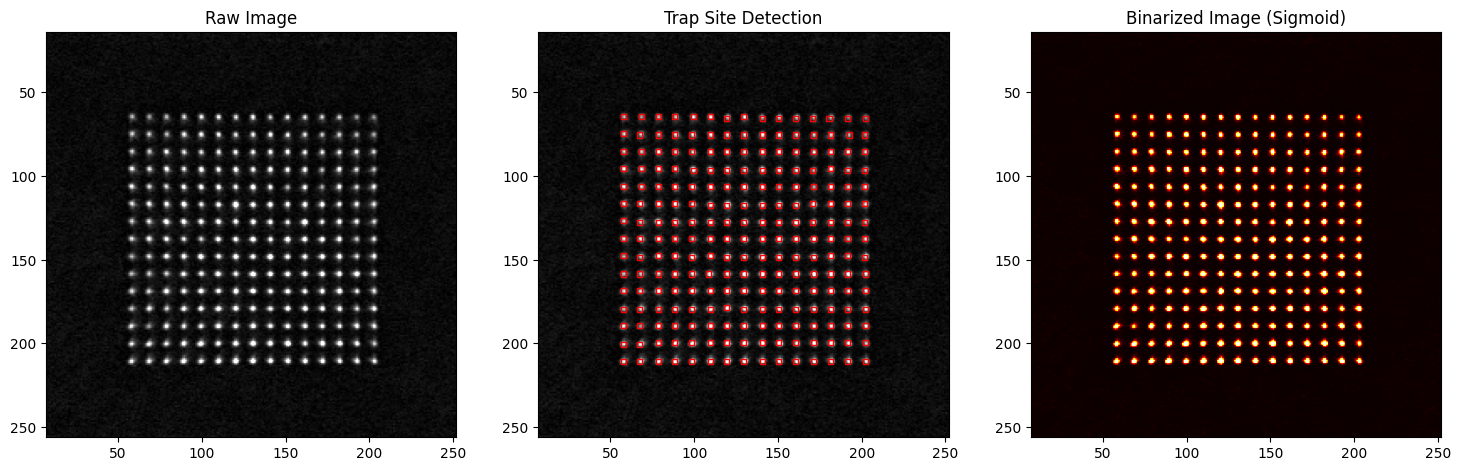

Trap (0, 0) Loading Probability : 55.00 %
Trap (0, 1) Loading Probability : 47.00 %
Trap (0, 2) Loading Probability : 52.00 %
Trap (0, 3) Loading Probability : 50.00 %
Trap (0, 4) Loading Probability : 59.00 %
Trap (0, 5) Loading Probability : 55.00 %
Trap (0, 6) Loading Probability : 53.00 %
Trap (0, 7) Loading Probability : 58.00 %
Trap (0, 8) Loading Probability : 51.00 %
Trap (0, 9) Loading Probability : 50.00 %
Trap (0, 10) Loading Probability : 51.00 %
Trap (0, 11) Loading Probability : 54.00 %
Trap (0, 12) Loading Probability : 60.00 %
Trap (0, 13) Loading Probability : 46.00 %
Trap (0, 14) Loading Probability : 50.00 %
Trap (1, 0) Loading Probability : 59.00 %
Trap (1, 1) Loading Probability : 55.00 %
Trap (1, 2) Loading Probability : 46.00 %
Trap (1, 3) Loading Probability : 61.00 %
Trap (1, 4) Loading Probability : 58.00 %
Trap (1, 5) Loading Probability : 61.00 %
Trap (1, 6) Loading Probability : 47.00 %
Trap (1, 7) Loading Probability : 55.00 %
Trap (1, 8) Loading Probabili

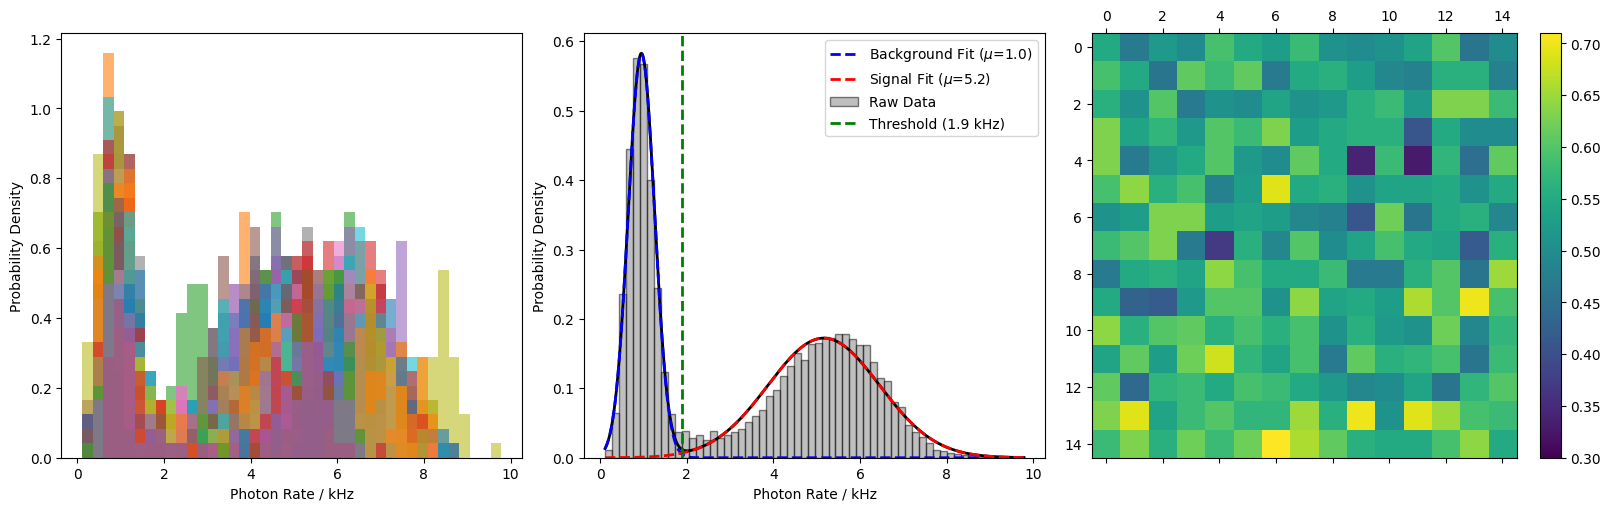

In [69]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"),
                                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue")})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=False, vmaxfactor=0.6, show_grid=True)

array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

In [ ]:
# Experiment and camera setup
n_iterations = 10
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO")})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=False, vmaxfactor=0.6, show_grid=True)

In [30]:
ExpParams.add_parameter("tMolCoolVCO1", best_params[0])
ExpParams.add_parameter("tMolRepVCO1", best_params[1])
ExpParams.add_parameter("tMolCoolVVA1", best_params[2])
ExpParams.add_parameter("tMolRepVVA1", best_params[3])
ExpParams.add_parameter("tMolCoolVCO2", best_params[4])
ExpParams.add_parameter("tMolRepVCO2", best_params[5])
ExpParams.add_parameter("tMolCoolVVA2", best_params[6])
ExpParams.add_parameter("tMolRepVVA2", best_params[7])

### Imaging Optimisation

In [ ]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

N_scan, M_scan = 10, 10

img_cool_vco_list = np.linspace(0.0, 3.0, N_scan)
img_cool_vva_list = np.linspace(0.4, 1.0, M_scan)

loading_prob_matrix = np.zeros((len(img_cool_vco_list), len(img_cool_vva_list)))
survival_prob_matrix = np.zeros((len(img_cool_vco_list), len(img_cool_vva_list)))
fidelity_matrix = np.zeros((len(img_cool_vco_list), len(img_cool_vva_list)))

for i,j in np.ndindex(len(img_cool_vco_list), len(img_cool_vva_list)):
    img_cool_vco = img_cool_vco_list[i]
    img_cool_vva = img_cool_vva_list[j]

    hamcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"),
                                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                                    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                                    "BackgroundDrop": 0, "tImgCoolVCO1": img_cool_vco, "tImgCoolVCO2": img_cool_vco, "tImgCoolVVA1": img_cool_vva, "tImgCoolVVA2": img_cool_vva})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=False, vmaxfactor=0.6, show_grid=True)
    imgs_filtered_1 = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]

    photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)

    mean_loading_probability = np.mean(loading_probabilities)
    survival_probability = extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, array_shape, window_size=window)

    if fidelity > 0.99:
        loading_prob_matrix[i, j] = mean_loading_probability
        survival_prob_matrix[i, j] = survival_probability
        fidelity_matrix[i, j] = fidelity

    print(f"Index ({i}, {j})  |  ImgCoolVCO = {img_cool_vco:.2f} V, ImgCoolVVA = {img_cool_vva:.2f} V  |  Mean Loading Probability = {mean_loading_probability:.4f}, Survival Probability = {survival_probability:.4f}, Fidelity = {fidelity:.4f}")


---

In [80]:
import json
json_file = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\pytweezer\\experiment\\saved_exp_parameters.json"

# Open the json file in read mode and load the data
with open(json_file, 'r') as f:
    data = json.load(f)

data = {'motmaster_parameters': {
            'tMOTLoadCoolVCO': 4.2631578947368425,
            'tMOTLoadRepVCO': 1.5789473684210527,
            'tMolCoolVCO1': 3.0,
            'tMolRepVCO1': 3.11082537869259,
            'tMolCoolVVA1': 1.0,
            'tMolRepVVA1': 0.5284897101402367,
            'tMolCoolVCO2': 0.0,
            'tMolRepVCO2': 3.259016009127741,
            'tMolCoolVVA2': 0.9895836703797966,
            'tMolRepVVA2': 0.7590677019962364,
            'tMOTShimXccValue': -1.9142550713624034,
            'tMOTShimYccValue': -2.3911971152849727,
            'tMOTShimZccValue': -0.22717632319839043
            },
        'misc_parameters': {
            'rep_vco_resonance': 5.0,
            'cool_vco_resonance': 4.7368421052631575
            },
        }

class ExpParameterManager():
    def __init__(self, json_file="C:\\Users\\tweez\\ColdMatter\\pytweezer\\pytweezer\\experiment\\saved_exp_parameters.json"):
        self.json_file = json_file
        self.load_parameters()

    def load_parameters(self, category=None):
        with open(self.json_file, 'r') as f:
            self.data = json.load(f)
        if category:
            return self.data.get(category, {})
        return self.data

    def get_parameter(self, param_name):
        for category in self.data.values():
            if param_name in category:
                return category[param_name]
        raise KeyError(f"Parameter '{param_name}' not found.")

    def set_parameter(self, param_name, value):
        for category in self.data.values():
            if param_name in category:
                category[param_name] = value
                return
        raise KeyError(f"Parameter '{param_name}' not found.")

    def save_parameters(self):
        with open(self.json_file, 'w') as f:
            json.dump(self.data, f, indent=4)

    def add_parameter(self, param_name, value, category="misc_parameters"):
        if category not in self.data:
            self.data[category] = {}
        self.data[category][param_name] = value

In [85]:
ParameterManager = ExpParameterManager(json_file=json_file)

p = ParameterManager.load_parameters()

ParameterManager.add_parameter("test_param", 10000, category="misc_parameters")

ParameterManager.save_parameters()
ParameterManager.load_parameters()

{'motmaster_parameters': {'tMOTLoadCoolVCO': 4.2631578947368425,
  'tMOTLoadRepVCO': 1.5789473684210527,
  'tMolCoolVCO1': 3.0,
  'tMolRepVCO1': 3.11082537869259,
  'tMolCoolVVA1': 1.0,
  'tMolRepVVA1': 0.5284897101402367,
  'tMolCoolVCO2': 0.0,
  'tMolRepVCO2': 3.259016009127741,
  'tMolCoolVVA2': 0.9895836703797966,
  'tMolRepVVA2': 0.7590677019962364,
  'tMOTShimXccValue': -1.9142550713624034,
  'tMOTShimYccValue': -2.3911971152849727,
  'tMOTShimZccValue': -0.22717632319839043,
  'test_param': 10000},
 'misc_parameters': {'rep_vco_resonance': 5.0,
  'cool_vco_resonance': 4.7368421052631575,
  'test_param': 10000}}

In [86]:
slm.close()
hamcam.close()
motcam.close()

SLM 1 closed.
ImagEM X2 camera closed.
Thorlabs TLCamera - motcam - closed.


In [ ]:
import json


class ExpParameterManager:
    def __init__(self, json_file="C:\\Users\\tweez\\ColdMatter\\pytweezer\\pytweezer\\experiment\\saved_exp_parameters.json"):
        self.json_file = json_file
        self.load_parameters()

    def _encode(self, obj):
        if isinstance(obj, tuple):
            return {"__tuple__": [self._encode(item) for item in obj]}
        if isinstance(obj, dict):
            return {"__dict__": [[self._encode(k), self._encode(v)] for k, v in obj.items()]}
        if isinstance(obj, list):
            return [self._encode(item) for item in obj]
        return obj

    def _decode(self, obj):
        if isinstance(obj, dict):
            if "__tuple__" in obj:
                return tuple(self._decode(item) for item in obj["__tuple__"])
            if "__dict__" in obj:
                return {
                    self._decode(k): self._decode(v)
                    for k, v in obj["__dict__"]
                }
            return {k: self._decode(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [self._decode(item) for item in obj]
        return obj

    def load_parameters(self, category=None):
        with open(self.json_file, "r") as f:
            raw_data = json.load(f)

        self.data = {cat: self._decode(values) for cat, values in raw_data.items()}

        if category:
            return self.data.get(category, {})
        return self.data

    def get_parameter(self, param_name):
        for category in self.data.values():
            if isinstance(category, dict) and param_name in category:
                return category[param_name]
        raise KeyError(f"Parameter '{param_name}' not found.")

    def set_parameter(self, param_name, value):
        for category in self.data.values():
            if isinstance(category, dict) and param_name in category:
                category[param_name] = value
                print(f"Parameter '{param_name}' set to {value}.")
                return
        raise KeyError(f"Parameter '{param_name}' not found.")

    def save_parameters(self):
        encoded_data = {cat: self._encode(values) for cat, values in self.data.items()}
        with open(self.json_file, "w") as f:
            json.dump(encoded_data, f, indent=4)
            print("Parameters saved.")

    def add_parameter(self, param_name, value, category="misc_parameters"):
        if category not in self.data:
            self.data[category] = {}
        self.data[category][param_name] = value
        print(f"Parameter '{param_name}': {value} added to category '{category}'.")

    def add_dictionary(self, category, dictionary):
        if category not in self.data:
            self.data[category] = {}
        if not isinstance(dictionary, dict):
            raise TypeError("dictionary must be a dict")
        self.data[category] = dictionary
        print(f"Dictionary added to category '{category}'.")